In [1]:
# Fix sys path to find modules in the project
import sys
sys.path.append("/Users/gccasini/GitHub/diplomatrixbr-eval")

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

In [2]:
from scripts.utils import get_mean

import base64
import io
from IPython.display import HTML
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import textwrap
import yaml

In [3]:
filepath = "/Users/gccasini/GitHub/diplomatrixbr-eval/prompt_testing/sheets/sabia_p7-12.csv"

df_eval = get_mean(filepath, 3)

df_eval[:24]

,judge,prompt,temp,redacao,nota_final,1A,1B,1C,CGPL,num_errors
0,sabia-3.1,7,0.0,1,54.0000,9.0000,9.0000,18.0000,18.0000,0.0000
1,sabia-3.1,7,0.5,1,52.6333,8.6667,8.6667,18.0000,17.3000,2.3333
2,sabia-3.1,7,0.9,1,51.6333,8.6667,9.0000,17.3333,16.6333,2.3333
3,sabia-3.1,8,0.0,1,55.7500,NaN,NaN,NaN,NaN,0.0000
4,sabia-3.1,8,0.5,1,57.2500,NaN,NaN,NaN,NaN,0.3333
5,sabia-3.1,8,0.9,1,56.8333,NaN,NaN,NaN,NaN,0.6667
6,sabia-3.1,9,0.0,1,55.0000,NaN,NaN,NaN,NaN,0.0000
7,sabia-3.1,9,0.5,1,55.0000,NaN,NaN,NaN,NaN,0.0000
8,sabia-3.1,9,0.9,1,56.6667,NaN,NaN,NaN,NaN,0.0000
9,sabia-3.1,10,0.0,1,54.0000,9.0000,9.0000,18.0000,18.0000,0.0000


In [4]:
df_human = pd.read_csv("/Users/gccasini/GitHub/diplomatrixbr-eval/prompt_testing/sheets/notas_humanas_2022.csv")
df_human.drop(columns=["versao", "prompt", "temp", "faixa"], inplace=True)

df_human

,judge,redacao,nota_final,1A,1B,1C,CGPL,num_errors
0,humano,1,55.5,10.0,9.5,18.0,18.0,0
1,humano,2,56.0,9.5,9.5,18.5,18.5,0
2,humano,3,58.0,10.0,10.0,19.0,19.0,0
3,humano,4,56.7,10.0,10.0,18.5,18.2,1
4,humano,5,54.7,9.5,9.5,18.0,17.7,1
5,humano,6,57.5,9.5,10.0,19.0,19.0,0


## Distribuição de Notas

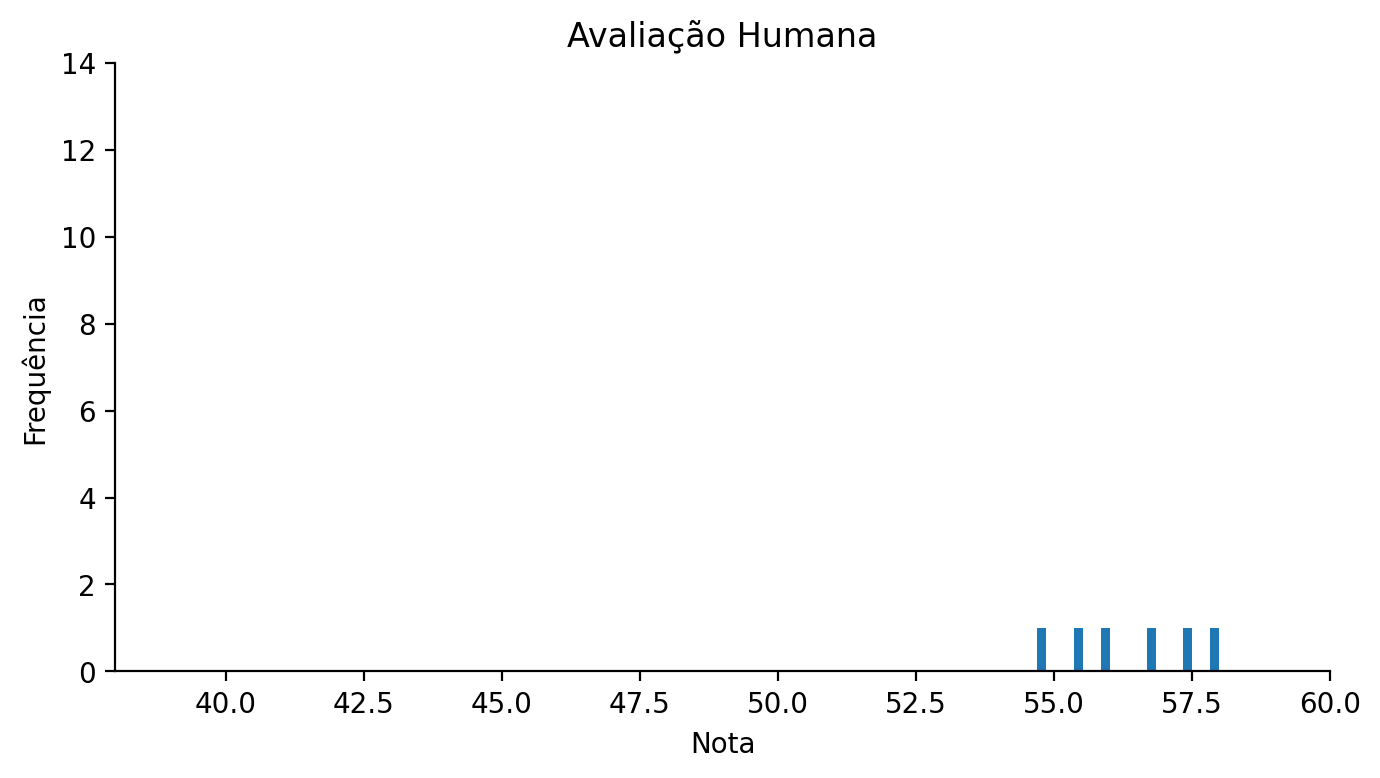

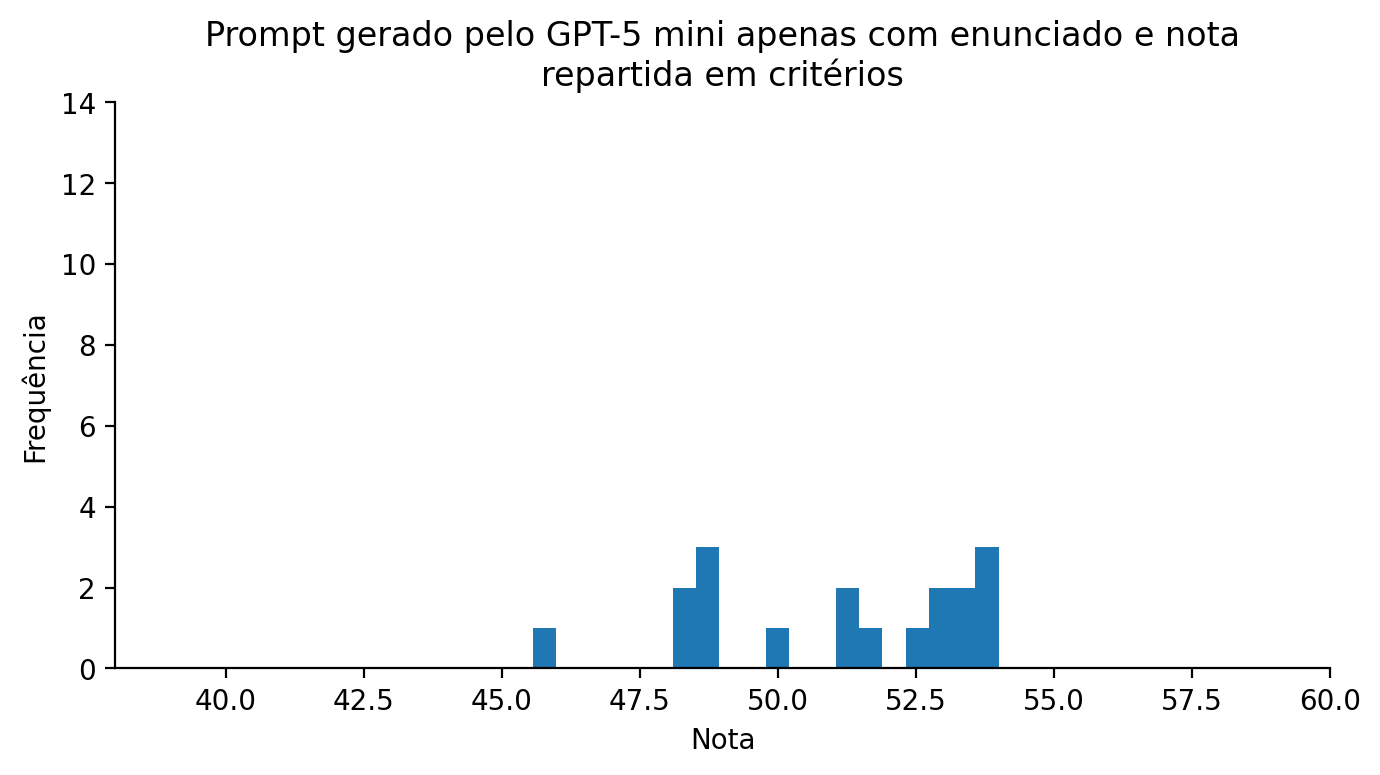

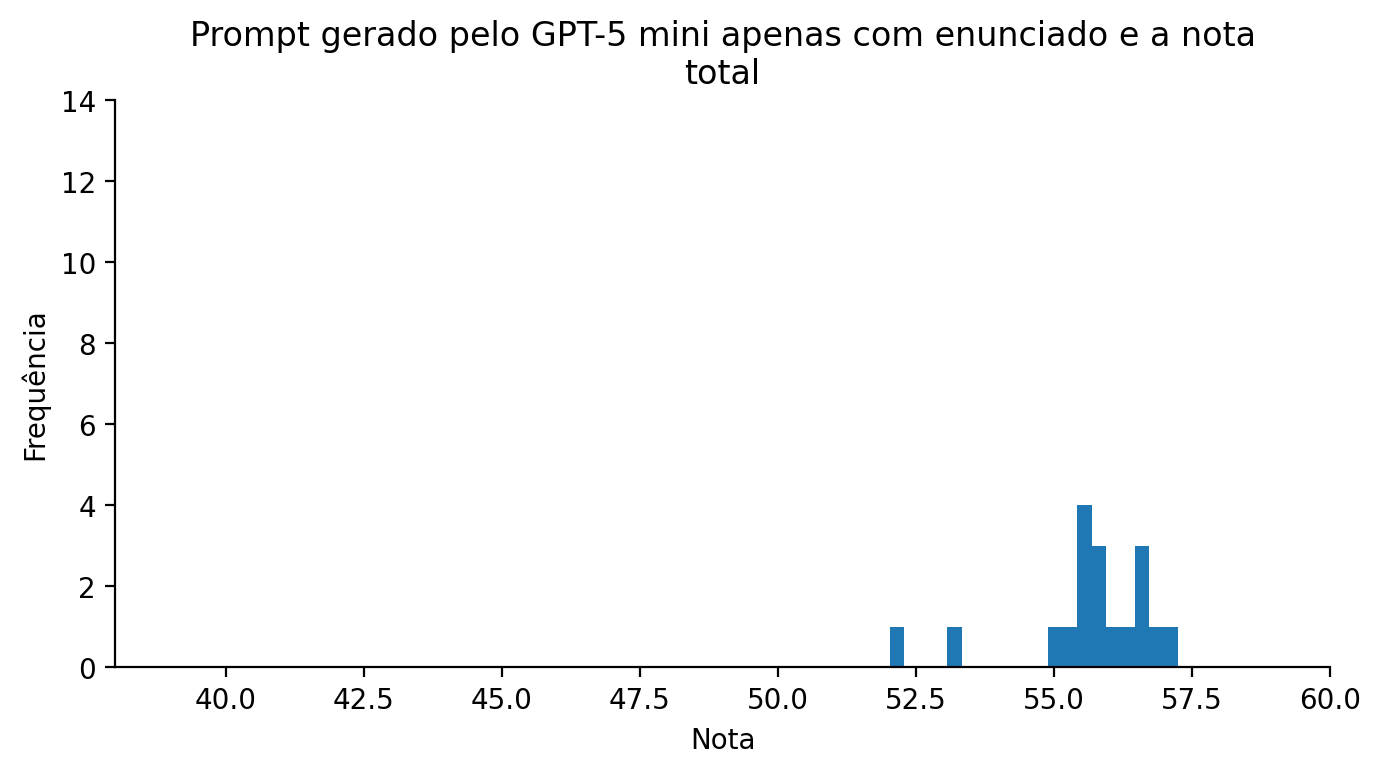

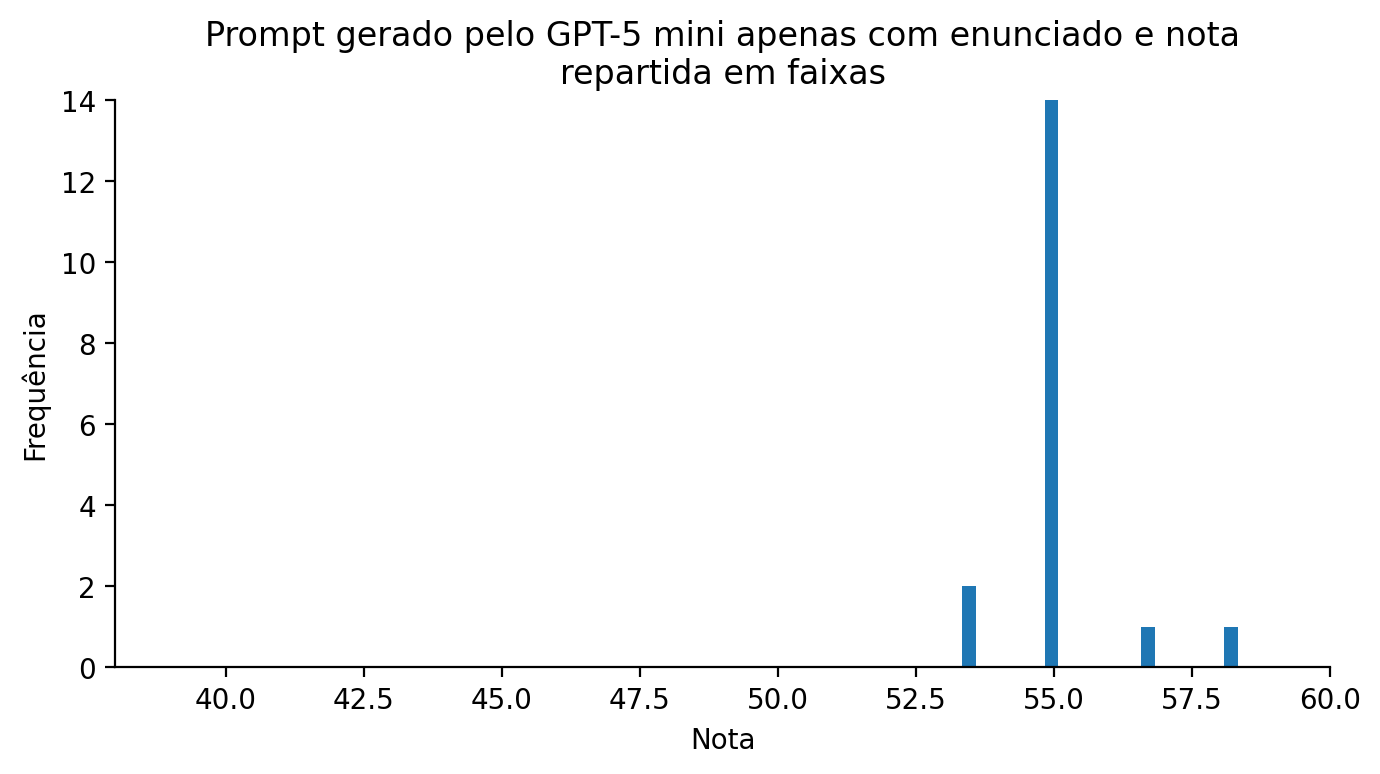

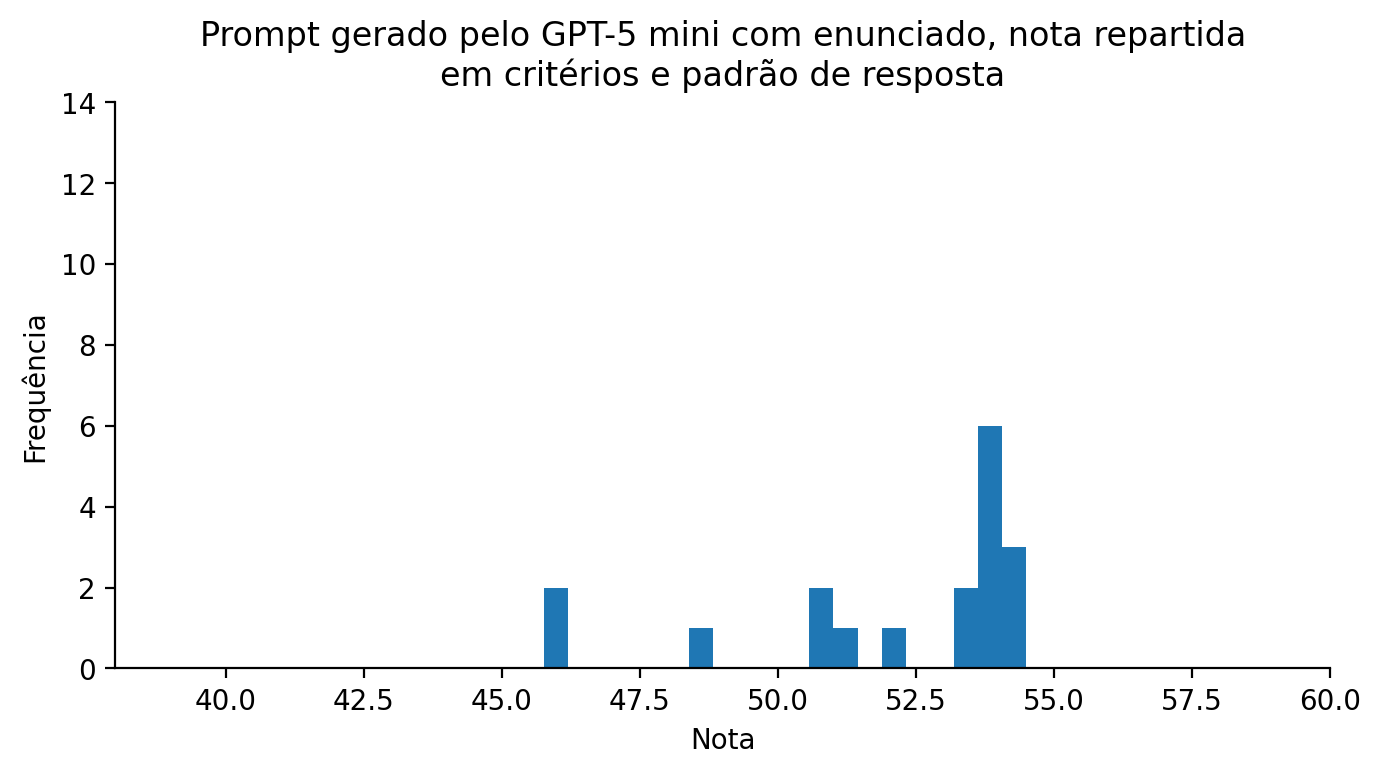

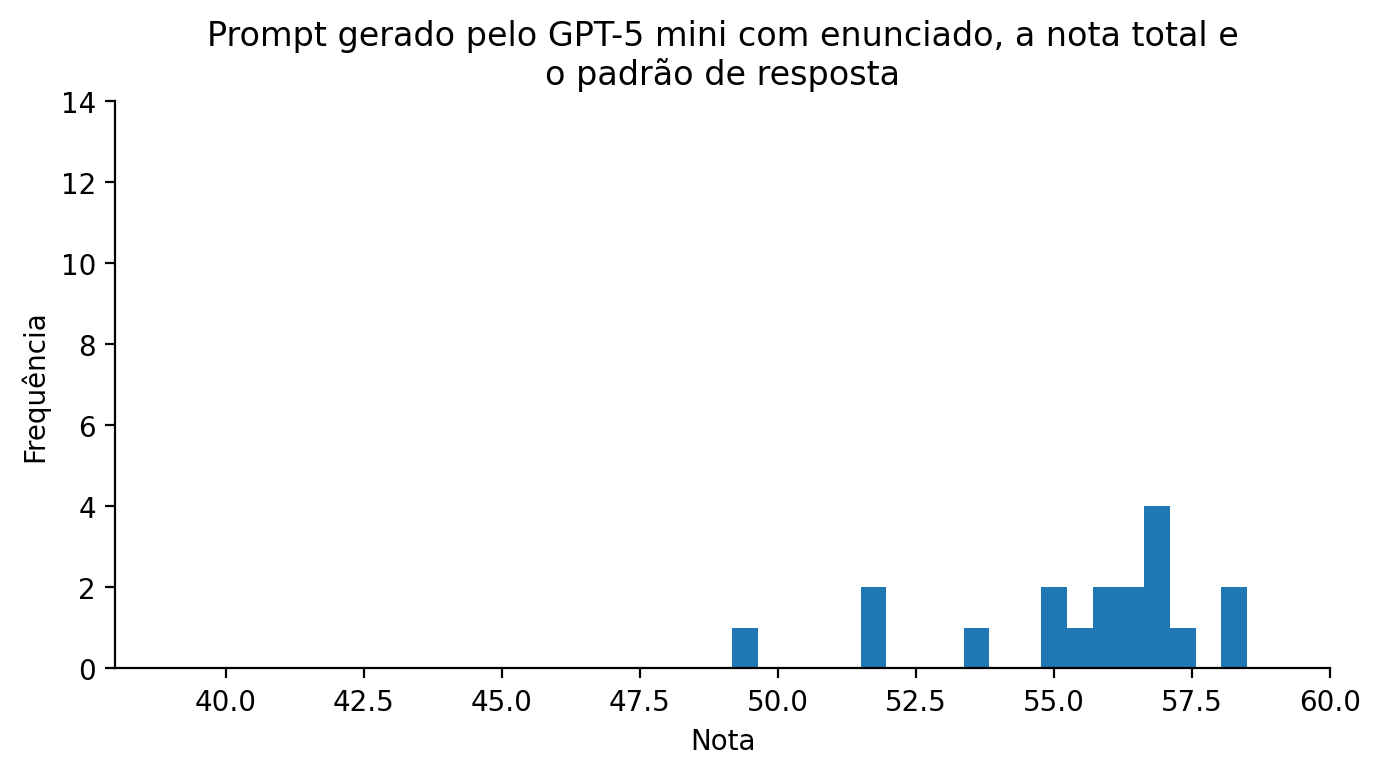

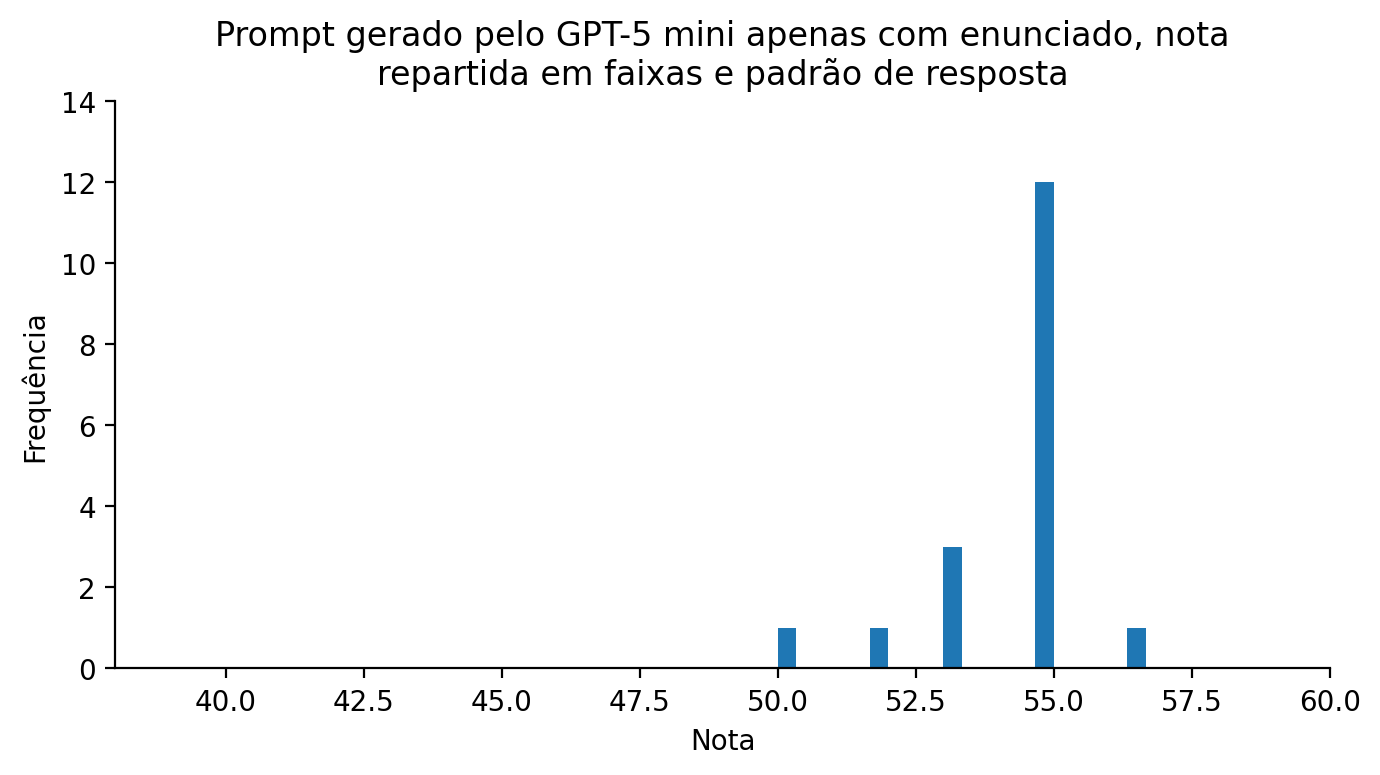

In [8]:
with open("/Users/gccasini/GitHub/diplomatrixbr-eval/prompt_testing/prompts.yaml", 'r', encoding='utf-8') as file:
    prompts_yaml = yaml.safe_load(file)
    prompts = prompts_yaml['prompts']

for i in [0, 7, 8, 9, 10, 11, 12]:

    if i == 0:
        subset = df_human
        title = "Avaliação Humana"
    else:
        subset = df_eval[df_eval['prompt'] == i]
        title = "\n".join(textwrap.wrap(prompts[i+1]["description"], width=60))
    plt.figure(figsize=(7, 4))

    subset['nota_final'].plot(
        kind='hist',
        bins=20,
        title=title,
        xlabel="Nota",
        ylabel="Frequência"
    )

    plt.xlim(38, 60)
    plt.ylim(0, 14)
    plt.gca().spines[['top', 'right']].set_visible(False)
    plt.tight_layout()
    plt.show()

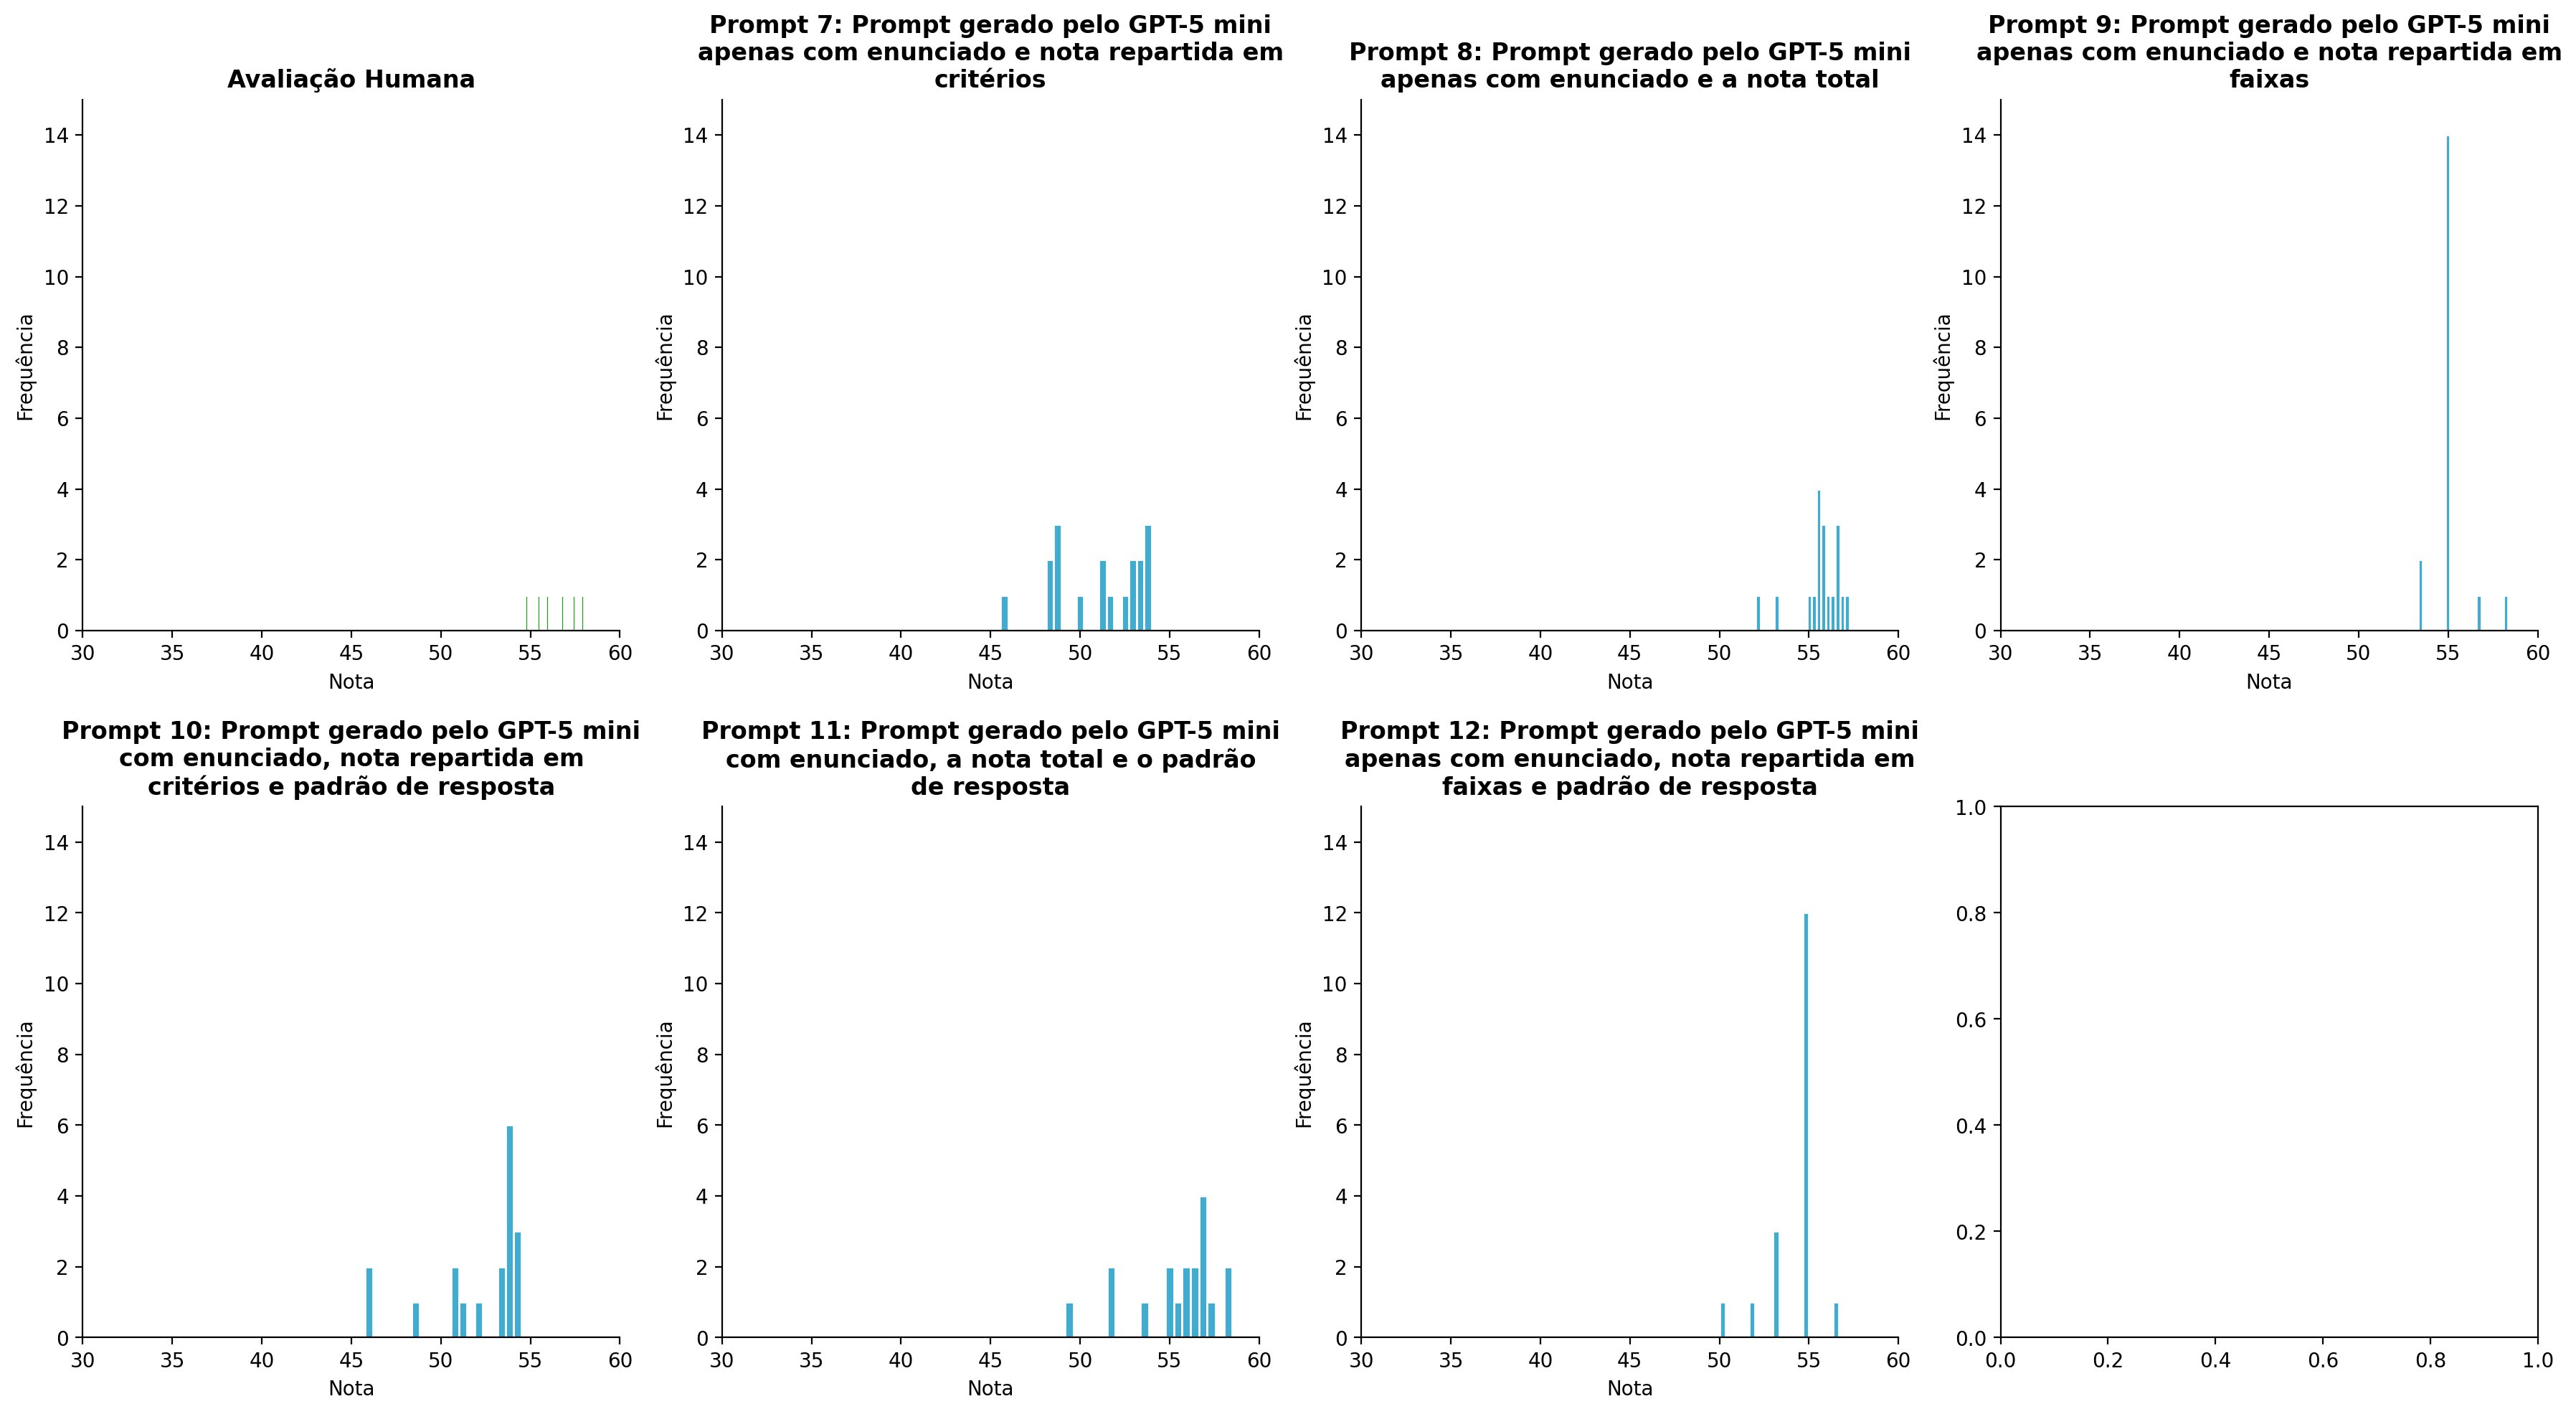

In [ ]:
import matplotlib.pyplot as plt
import textwrap
import math

def plot_histogram_grid(df_eval, df_human, prompts):
    plot_ids = [0] + df_eval["prompt"].unique().tolist()
    num_plots = len(plot_ids)
    ncols = 4
    nrows = math.ceil(num_plots / ncols)
    
    fig, axes = plt.subplots(nrows, ncols, figsize=(18, 5 * nrows))
    axes = axes.flatten()

    for idx, i in enumerate(plot_ids):
        ax = axes[idx]
        
        # Seleção de dados e título (Lógica original)
        if i == 0:
            subset = df_human
            title = "Avaliação Humana"
        else:
            subset = df_eval[df_eval['prompt'] == i]
            desc = f"Prompt {i}: " + prompts[i+1]["description"]
            title = "\n".join(textwrap.wrap(desc, width=40))

        subset['nota_final'].plot(kind='hist', bins=20, ax=ax, color="#41ACCF" if i != 0 else "#1E9D1E", edgecolor='white')

        ax.set_title(title, fontsize=12, fontweight='bold')
        ax.set_xlabel("Nota")
        ax.set_ylabel("Frequência")
        ax.set_xlim(30, 60)
        ax.set_ylim(0, 15)
        ax.spines[['top', 'right']].set_visible(False)

    # Remove eixos vazios
    for j in range(idx + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.savefig("grade_histogramas.png", dpi=300, bbox_inches='tight')
    plt.show()

# Para usar no seu script principal:
histogram_grid(df_eval, df_human, prompts)

In [ ]:
df_merged = df_eval.merge(
    df_human[["redacao", "nota_final"]].rename(columns={"nota_final": "nota_humana"}),
    on="redacao"
)

df_merged["val_error"] =  abs(df_merged["nota_humana"] - df_merged["nota_final"])

df_merged[:24]

,judge,prompt,temp,redacao,nota_final,1A,1B,1C,CGPL,num_errors,nota_humana,se,rmse,val_error
0,sabia-3.1,7,0.0,1,54.0000,9.0000,9.0000,18.0000,18.0000,0.0000,55.5,2.250000,1.5000,1.5000
1,sabia-3.1,7,0.5,1,52.6333,8.6667,8.6667,18.0000,17.3000,2.3333,55.5,8.217969,2.8667,2.8667
2,sabia-3.1,7,0.9,1,51.6333,8.6667,9.0000,17.3333,16.6333,2.3333,55.5,14.951369,3.8667,3.8667
3,sabia-3.1,8,0.0,1,55.7500,NaN,NaN,NaN,NaN,0.0000,55.5,0.062500,0.2500,0.2500
4,sabia-3.1,8,0.5,1,57.2500,NaN,NaN,NaN,NaN,0.3333,55.5,3.062500,1.7500,1.7500
5,sabia-3.1,8,0.9,1,56.8333,NaN,NaN,NaN,NaN,0.6667,55.5,1.777689,1.3333,1.3333
6,sabia-3.1,9,0.0,1,55.0000,NaN,NaN,NaN,NaN,0.0000,55.5,0.250000,0.5000,0.5000
7,sabia-3.1,9,0.5,1,55.0000,NaN,NaN,NaN,NaN,0.0000,55.5,0.250000,0.5000,0.5000
8,sabia-3.1,9,0.9,1,56.6667,NaN,NaN,NaN,NaN,0.0000,55.5,1.361189,1.1667,1.1667
9,sabia-3.1,10,0.0,1,54.0000,9.0000,9.0000,18.0000,18.0000,0.0000,55.5,2.250000,1.5000,1.5000


In [12]:
areas = {}

for (prompt, temp), group in df_merged.groupby(["prompt", "temp"]):  
    area = np.trapezoid(group["val_error"], group["redacao"])
    areas[(prompt, temp)] = prompt, temp, area.round(4)

df_area_sob_grafico = pd.DataFrame.from_dict(areas, orient='index', columns=['prompt', 'temp', 'area_val_error']).reset_index(drop=True)
df_area_sob_grafico

,prompt,temp,area_val_error
0,7,0.0,25.1000
1,7,0.5,25.6666
2,7,0.9,32.1999
3,8,0.0,5.7917
4,8,0.5,6.7217
5,8,0.9,10.1667
6,9,0.0,7.5000
7,9,0.5,9.1667
8,9,0.9,10.8334
9,10,0.0,22.0334


prompt,temp,area_rmse
8,0.0,5.7917
8,0.5,6.7217
12,0.0,7.5000
9,0.0,7.5000
9,0.5,9.1667
11,0.5,9.8333
8,0.9,10.1667
9,0.9,10.8334
12,0.5,11.9001
11,0.9,13.2083

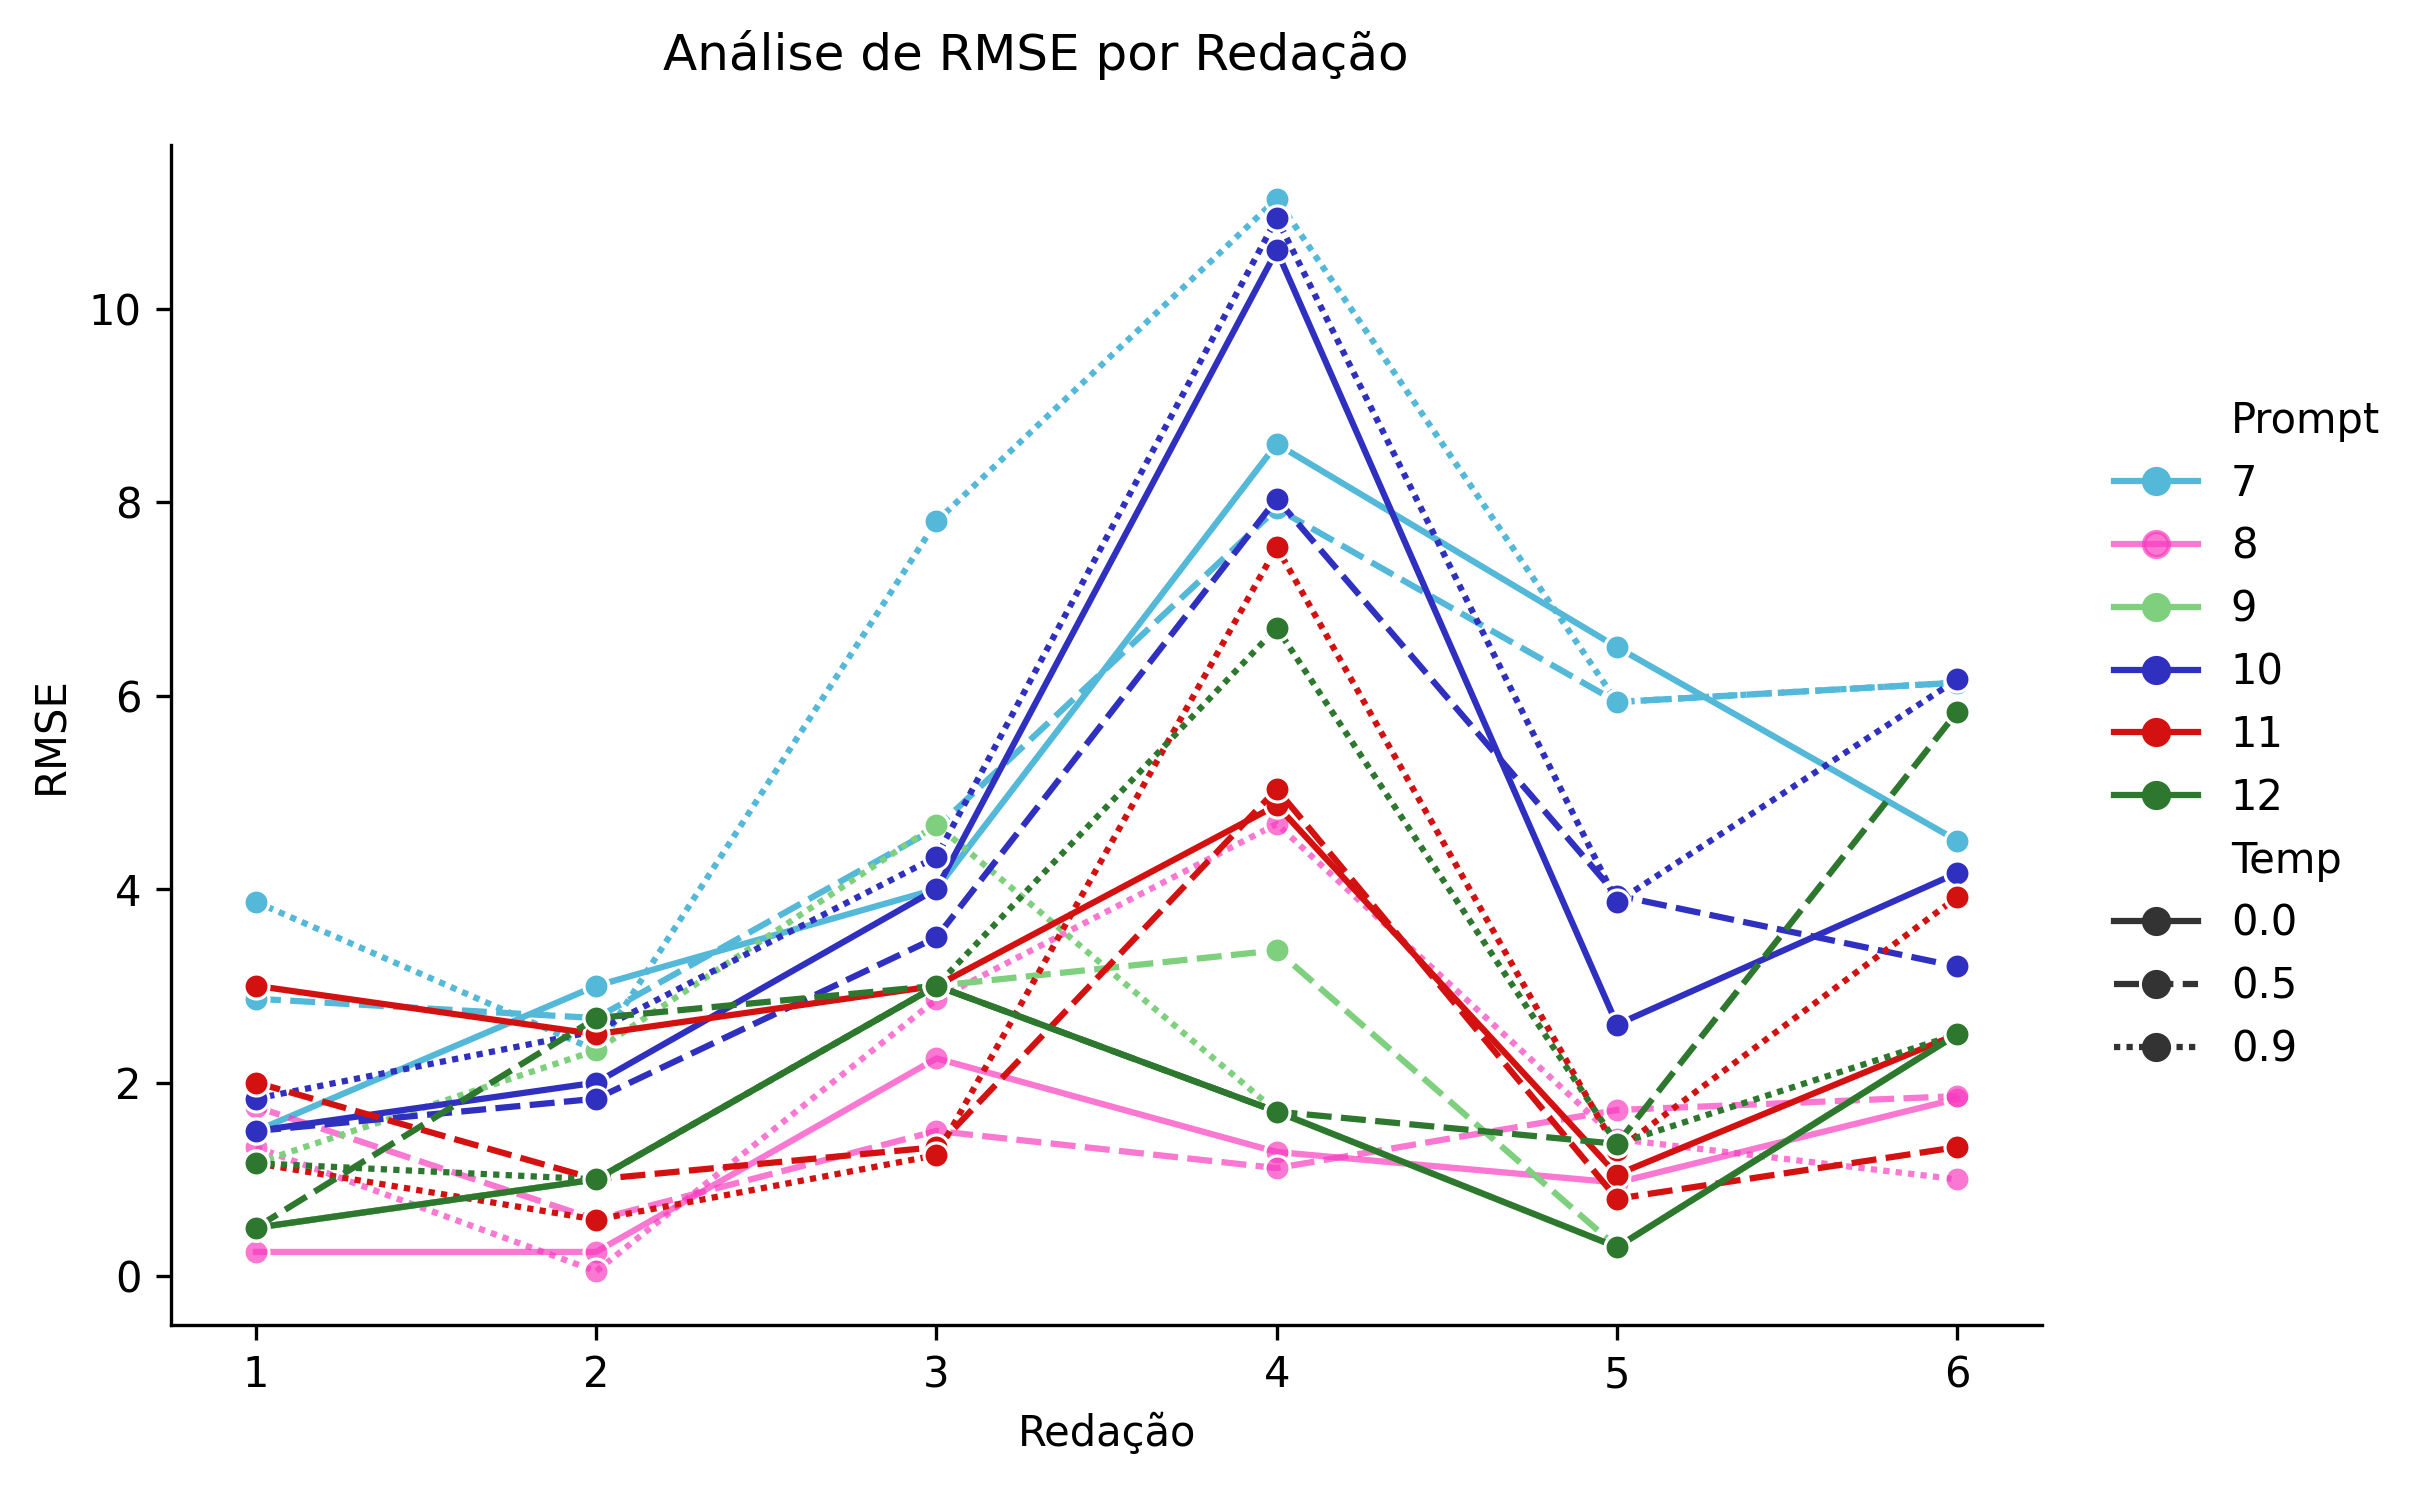

In [ ]:
g = sns.relplot(
    data=df_merged,
    x="redacao",
    y="rmse",
    hue="prompt",
    style="temp",
    kind="line",
    marker="o",
    height=5,
    aspect=1.2,
    palette = ["#54B8D9", "#F83BBFB1", "#7ED07E", "#3030C0", "#D41111", "#2E772E"]
)

g._legend.set_bbox_to_anchor((1.15, 0.5))

plt.suptitle("Análise de Erro de Validação")
plt.tight_layout()
plt.xlabel("Redação")
plt.ylabel("Erro")
plt.savefig("area_val_error.png", dpi=300, bbox_inches='tight')

buf = io.BytesIO()
plt.savefig(buf, format='png', dpi=300, bbox_inches='tight')
buf.seek(0)
encoded = base64.b64encode(buf.read()).decode('utf-8')

html = f"""
<div style="display: flex; align-items: flex-start; gap: 30px;">
    <div style="flex: 1;">
        <img src="data:image/png;base64,{encoded}">
    </div>
    <div></div><br>
    <div style="flex: 0.8; align-self: center;">
        {df_area_sob_grafico.to_html(index=False)}
    </div>
</div>
"""

display(HTML(html))

plt.close()

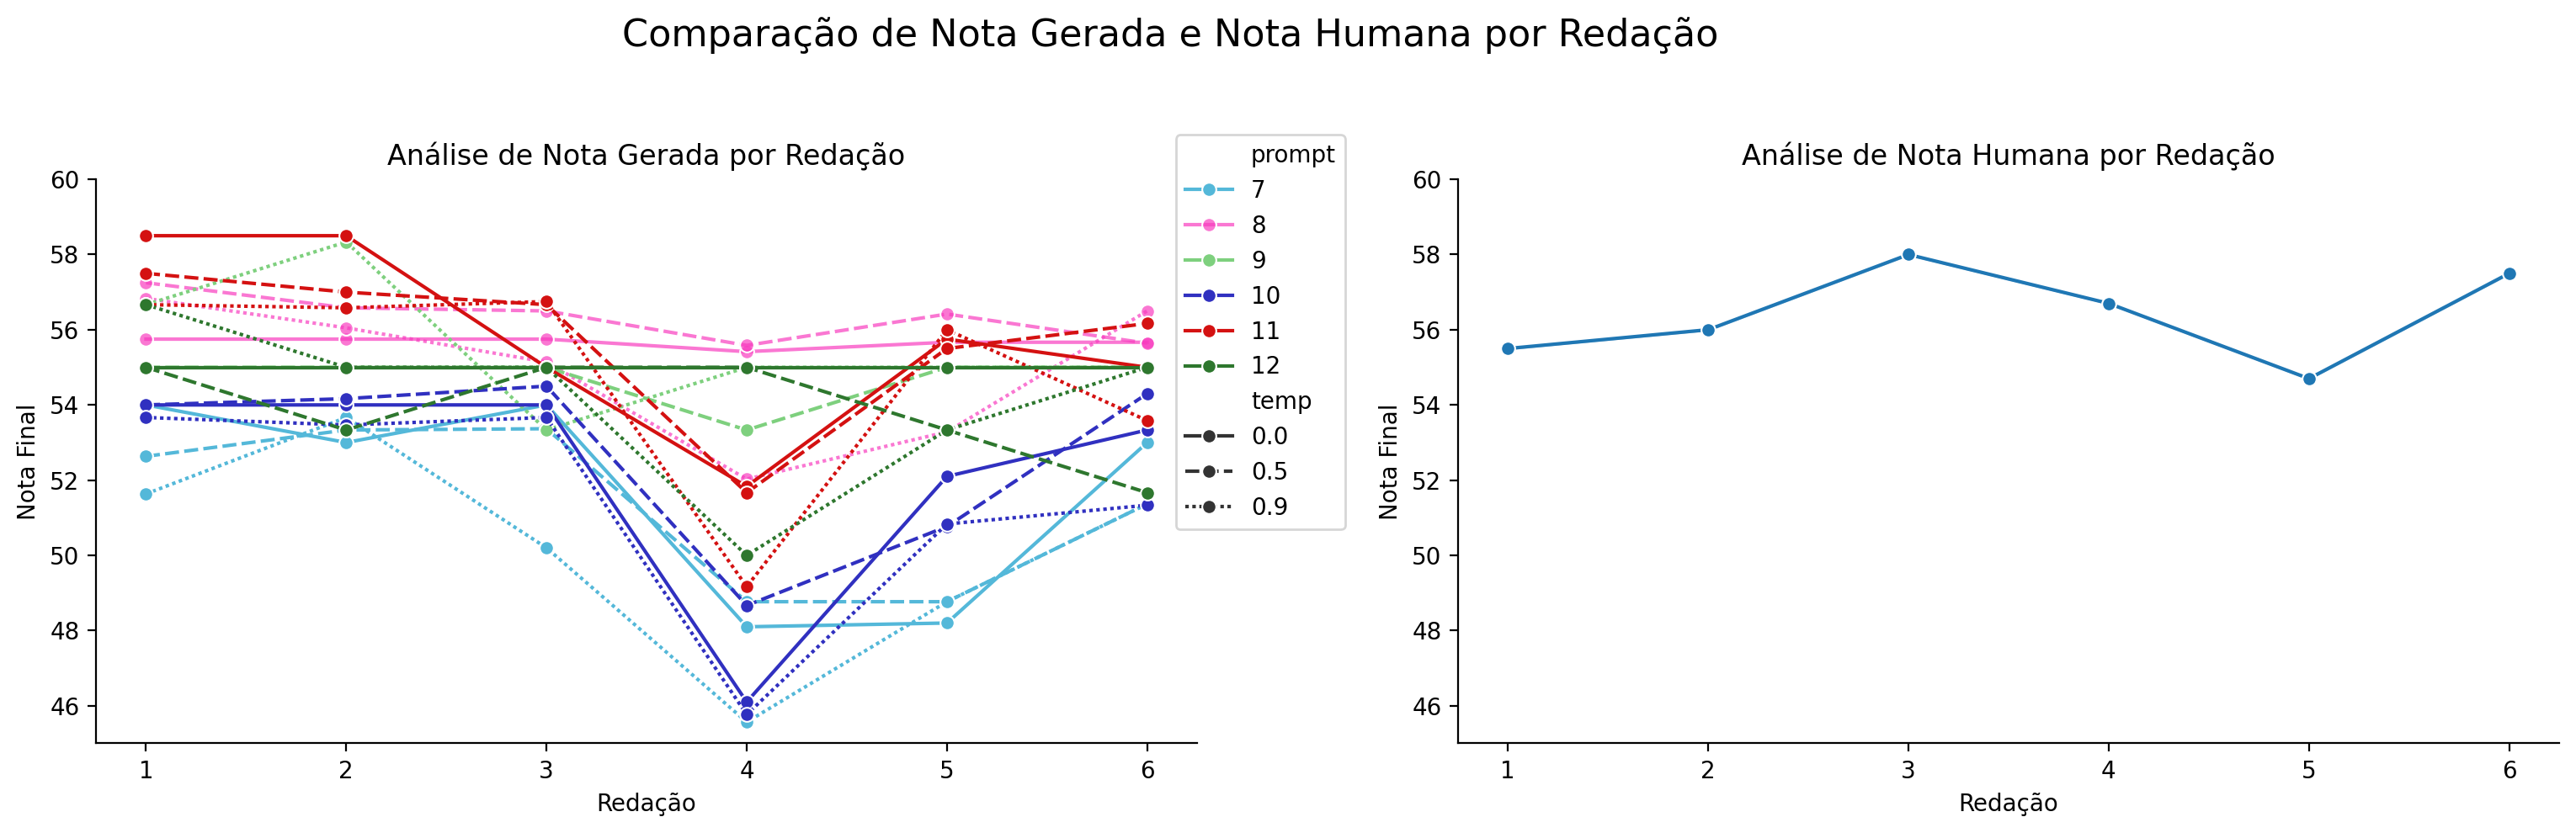

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.lineplot(
    data=df_merged,
    x="redacao",
    y="nota_final",
    hue="prompt",
    style="temp",
    marker="o",
    palette=["#54B8D9", "#F83BBFB1", "#7ED07E", "#3030C0", "#D41111", "#2E772E"],
    ax=axes[0]
)
axes[0].set_title("Análise de Nota Gerada por Redação")
axes[0].set_xlabel("Redação")
axes[0].set_ylabel("Nota Final")
axes[0].set_ylim(45, 60)
axes[0].legend(bbox_to_anchor=(0.97, 1.1), loc="upper left")
axes[0].spines[['top', 'right']].set_visible(False)

sns.lineplot(
    data=df_merged,
    x="redacao",
    y="nota_humana",
    marker="o",
    ax=axes[1]
)
axes[1].set_title("Análise de Nota Humana por Redação")
axes[1].set_xlabel("Redação")
axes[1].set_ylabel("Nota Final")
axes[1].set_ylim(45, 60)
axes[1].spines[['top', 'right']].set_visible(False)

plt.suptitle("Comparação de Nota Gerada e Nota Humana por Redação", fontsize=16)
plt.tight_layout(rect=[0, 0, 1.1, 0.95])
plt.show()


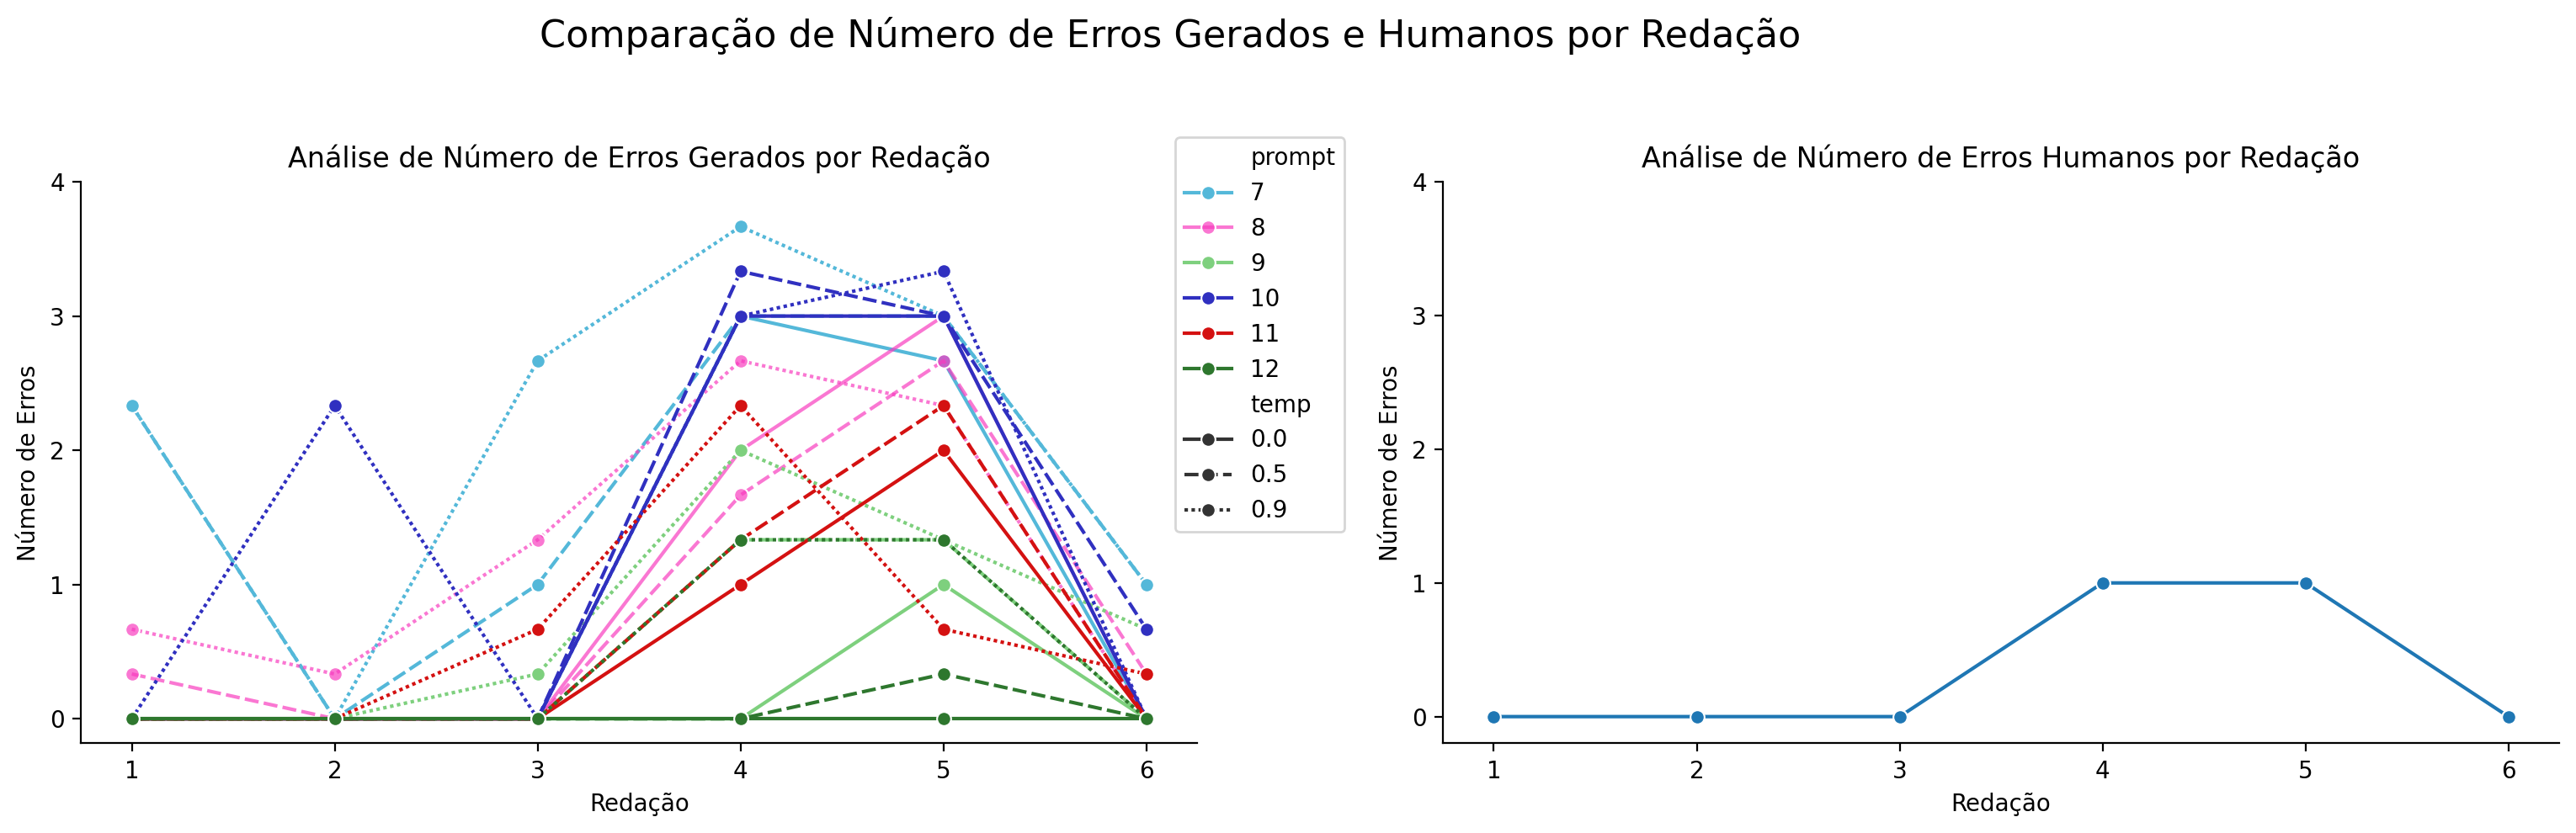

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.lineplot(
    data=df_merged,
    x="redacao",
    y="num_errors",
    hue="prompt",
    style="temp",
    marker="o",
    palette=["#54B8D9", "#F83BBFB1", "#7ED07E", "#3030C0", "#D41111", "#2E772E"],
    ax=axes[0]
)
axes[0].set_title("Análise de Número de Erros Gerados por Redação")
axes[0].set_xlabel("Redação")
axes[0].set_ylabel("Número de Erros")
axes[0].set_yticks([0, 1, 2, 3, 4])
axes[0].legend(bbox_to_anchor=(0.97, 1.1), loc="upper left")
axes[0].spines[['top', 'right']].set_visible(False)

sns.lineplot(
    data=df_human,
    x="redacao",
    y="num_errors",
    marker="o",
    ax=axes[1]
)
axes[1].set_title("Análise de Número de Erros Humanos por Redação")
axes[1].set_xlabel("Redação")
axes[1].set_ylabel("Número de Erros")
axes[1].set_yticks([0, 1, 2, 3, 4])
axes[1].set_ylim(-0.2, 4)
axes[1].spines[['top', 'right']].set_visible(False)

plt.suptitle("Comparação de Número de Erros Gerados e Humanos por Redação", fontsize=16)
plt.tight_layout(rect=[0, 0, 1.1, 0.95])
plt.show()
